<a href="https://colab.research.google.com/github/antoniovfonseca/agentic-ai-global-lulc/blob/main/notebooks/transition-matrix-gee-glance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Environment Setup

First, we will import the necessary libraries to handle spatial data processing.

In [1]:
# Install dependency
!pip install geemap -q > /dev/null 2>&1
!apt-get install -y gdal-bin -q > /dev/null 2>&1
!pip install matplotlib-scalebar -q > /dev/null 2>&1

In [42]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.1 Import libraries and GitHub repository

In [58]:
# Import libraries
import pandas as pd
import ee
import os
import sys
import geemap


# Define repository details
repo_url = 'https://github.com/antoniovfonseca/agentic-ai-global-lulc.git'
repo_name = 'agentic-ai-global-lulc'

# Clone or update the repository
if not os.path.exists(repo_name):
    print(f"Cloning {repo_name}...")
    !git clone {repo_url}
else:
    print(f"Updating {repo_name}...")
    !cd {repo_name} && git pull

# Add the notebooks directory to system path to allow imports
notebooks_path = os.path.join(repo_name, 'notebooks')
if notebooks_path not in sys.path:
    sys.path.append(os.path.abspath(notebooks_path))
    print(f"Added {notebooks_path} to system path.")

import importlib
import utils

importlib.reload(utils)
print("Utils module loaded successfully.")

Updating agentic-ai-global-lulc...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.00 KiB | 171.00 KiB/s, done.
From https://github.com/antoniovfonseca/agentic-ai-global-lulc
   196dd5d..0c70c3c  main       -> origin/main
Updating 196dd5d..0c70c3c
Fast-forward
 notebooks/utils.py | 4 ++--
 1 file changed, 2 insertions(+), 2 deletions(-)
Added agentic-ai-global-lulc/notebooks to system path.
Utils module loaded successfully.


## 1.2 Global Configuration

In [4]:
# 1. GEE User
user = 'ee-antoniovicgf'

# 2. Global Directory Paths
gee_drive_folder = "GLANCE_Global_Transitions_300m"
base_drive_dir = f"/content/drive/MyDrive/{gee_drive_folder}"

# 3. Define the time points
#years_to_process = list(range(2001, 2020))
years_to_process = [2001, 2010, 2019]


In [5]:
# Authenticate and initialize Earth Engine using the global 'user' variable
try:
    ee.Initialize(project=user)
    print(f"Earth Engine initialized successfully for project: {user}")
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=user)
    print(f"Earth Engine authenticated and initialized for project: {user}")


Earth Engine authenticated and initialized for project: ee-antoniovicgf


# 2.GLanCE Visualization

In [6]:
# Define parameters
target_year = 2019

# Run the function imported from utils.py
glance_map = utils.get_glance_map(target_year)

# Display the map
if glance_map:
    display(glance_map)

Map(center=[20, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', trans…

# 3.Class Area at Time Points

In [ ]:
# Trigger the export tasks via the utils function using global config
print("Starting global pixel count exports via GEE...")
tasks_counts = utils.export_global_pixel_counts_tasks(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=300
)

print(f"\nSuccess! {len(tasks_counts)} count tasks have been submitted to GEE.")


Starting global pixel count exports via GEE...
Task started: Pixel_Counts_LULC_2001 (Scale: 300m)
Task started: Pixel_Counts_LULC_2010 (Scale: 300m)
Task started: Pixel_Counts_LULC_2019 (Scale: 300m)

Success! 3 count tasks have been submitted to GEE.


Generating the bar chart from GEE CSVs...
Chart successfully saved at: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/chart_pixel_per_class_net_change.png


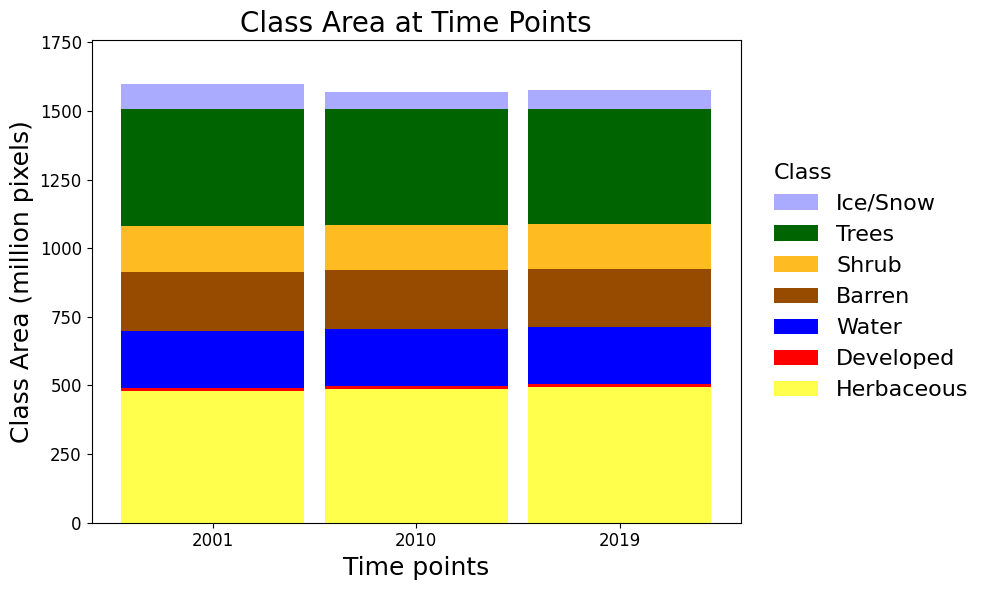

In [ ]:
# Call the updated function to generate the plot using global directories
print("Generating the bar chart from GEE CSVs...")
utils.plot_pixel_counts_bar_chart(
    input_dir=base_drive_dir,
    class_labels_dict=utils.GLANCE_METADATA,
    output_dir=base_drive_dir
)


# 4.Number of Changes

## 4.1 Export compute number of changes task to GEE

In [ ]:
# 1. Trigger the tasks for the Number of Changes section using the function from utils.py
print("Submitting Number of Changes Tasks to GEE...")

change_freq_tasks = utils.export_global_change_frequency_tasks(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=300,
)

print(f"\nSuccess! {len(change_freq_tasks)} tasks submitted to GEE.")



Submitting Number of Changes Tasks to GEE...
Task started: Number_Change_2001_2010 (Scale: 300m)
Task started: Number_Change_2010_2019 (Scale: 300m)

Success! 2 tasks submitted to GEE.


## 4.2 Plot Number of Changes during Time Intervals chart

Generating the chart from GEE CSVs...


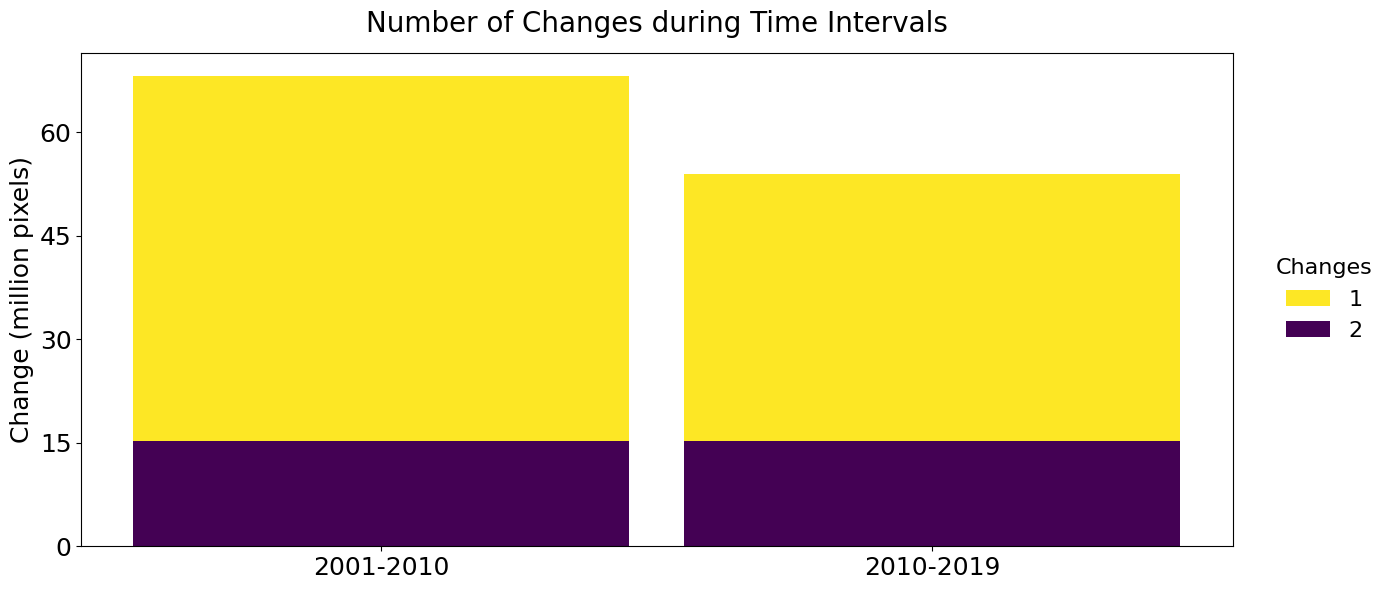

Chart saved to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/chart_number_change_time_interval.png


In [ ]:
# 2. Execute the plotting function reading directly from the Drive folder
# Note: Wait until the GEE tasks finish exporting to run this part!
print("Generating the chart from GEE CSVs...")

utils.plot_global_change_frequency_bar_chart(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
)


## 4.3 Plot Number of Changes Overall

Generating the overall changes distribution chart...


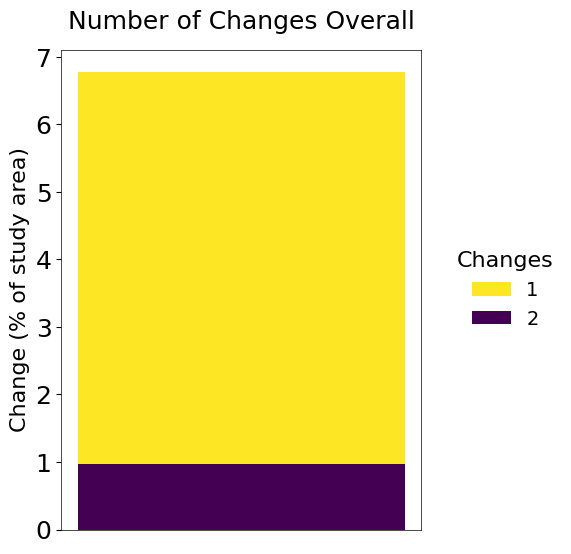

Chart saved to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/chart_number_changes_percentage_overall.png


In [ ]:
print("Generating the overall changes distribution chart...")
utils.plot_number_of_changes_distribution(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
)

## 4.4 Export Number of Changes raster map task to GEE

In [ ]:
import importlib
import utils
importlib.reload(utils)

print("Submitting Number of Changes Raster Task to GEE...")
num_changes_raster_task = utils.export_global_number_of_changes_raster_task(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=300,
)
print("\nSuccess! Raster export task submitted to GEE. Check the Tasks tab.")

Submitting Number of Changes Raster Task to GEE...
Task started: Number_of_Changes_Raster_2001_2019 (Scale: 300m, NoData: 255)

Success! Raster export task submitted to GEE. Check the Tasks tab.


## 4.5 Plot Number of Change map

Generating the global Number of Changes map from GEE rasters...


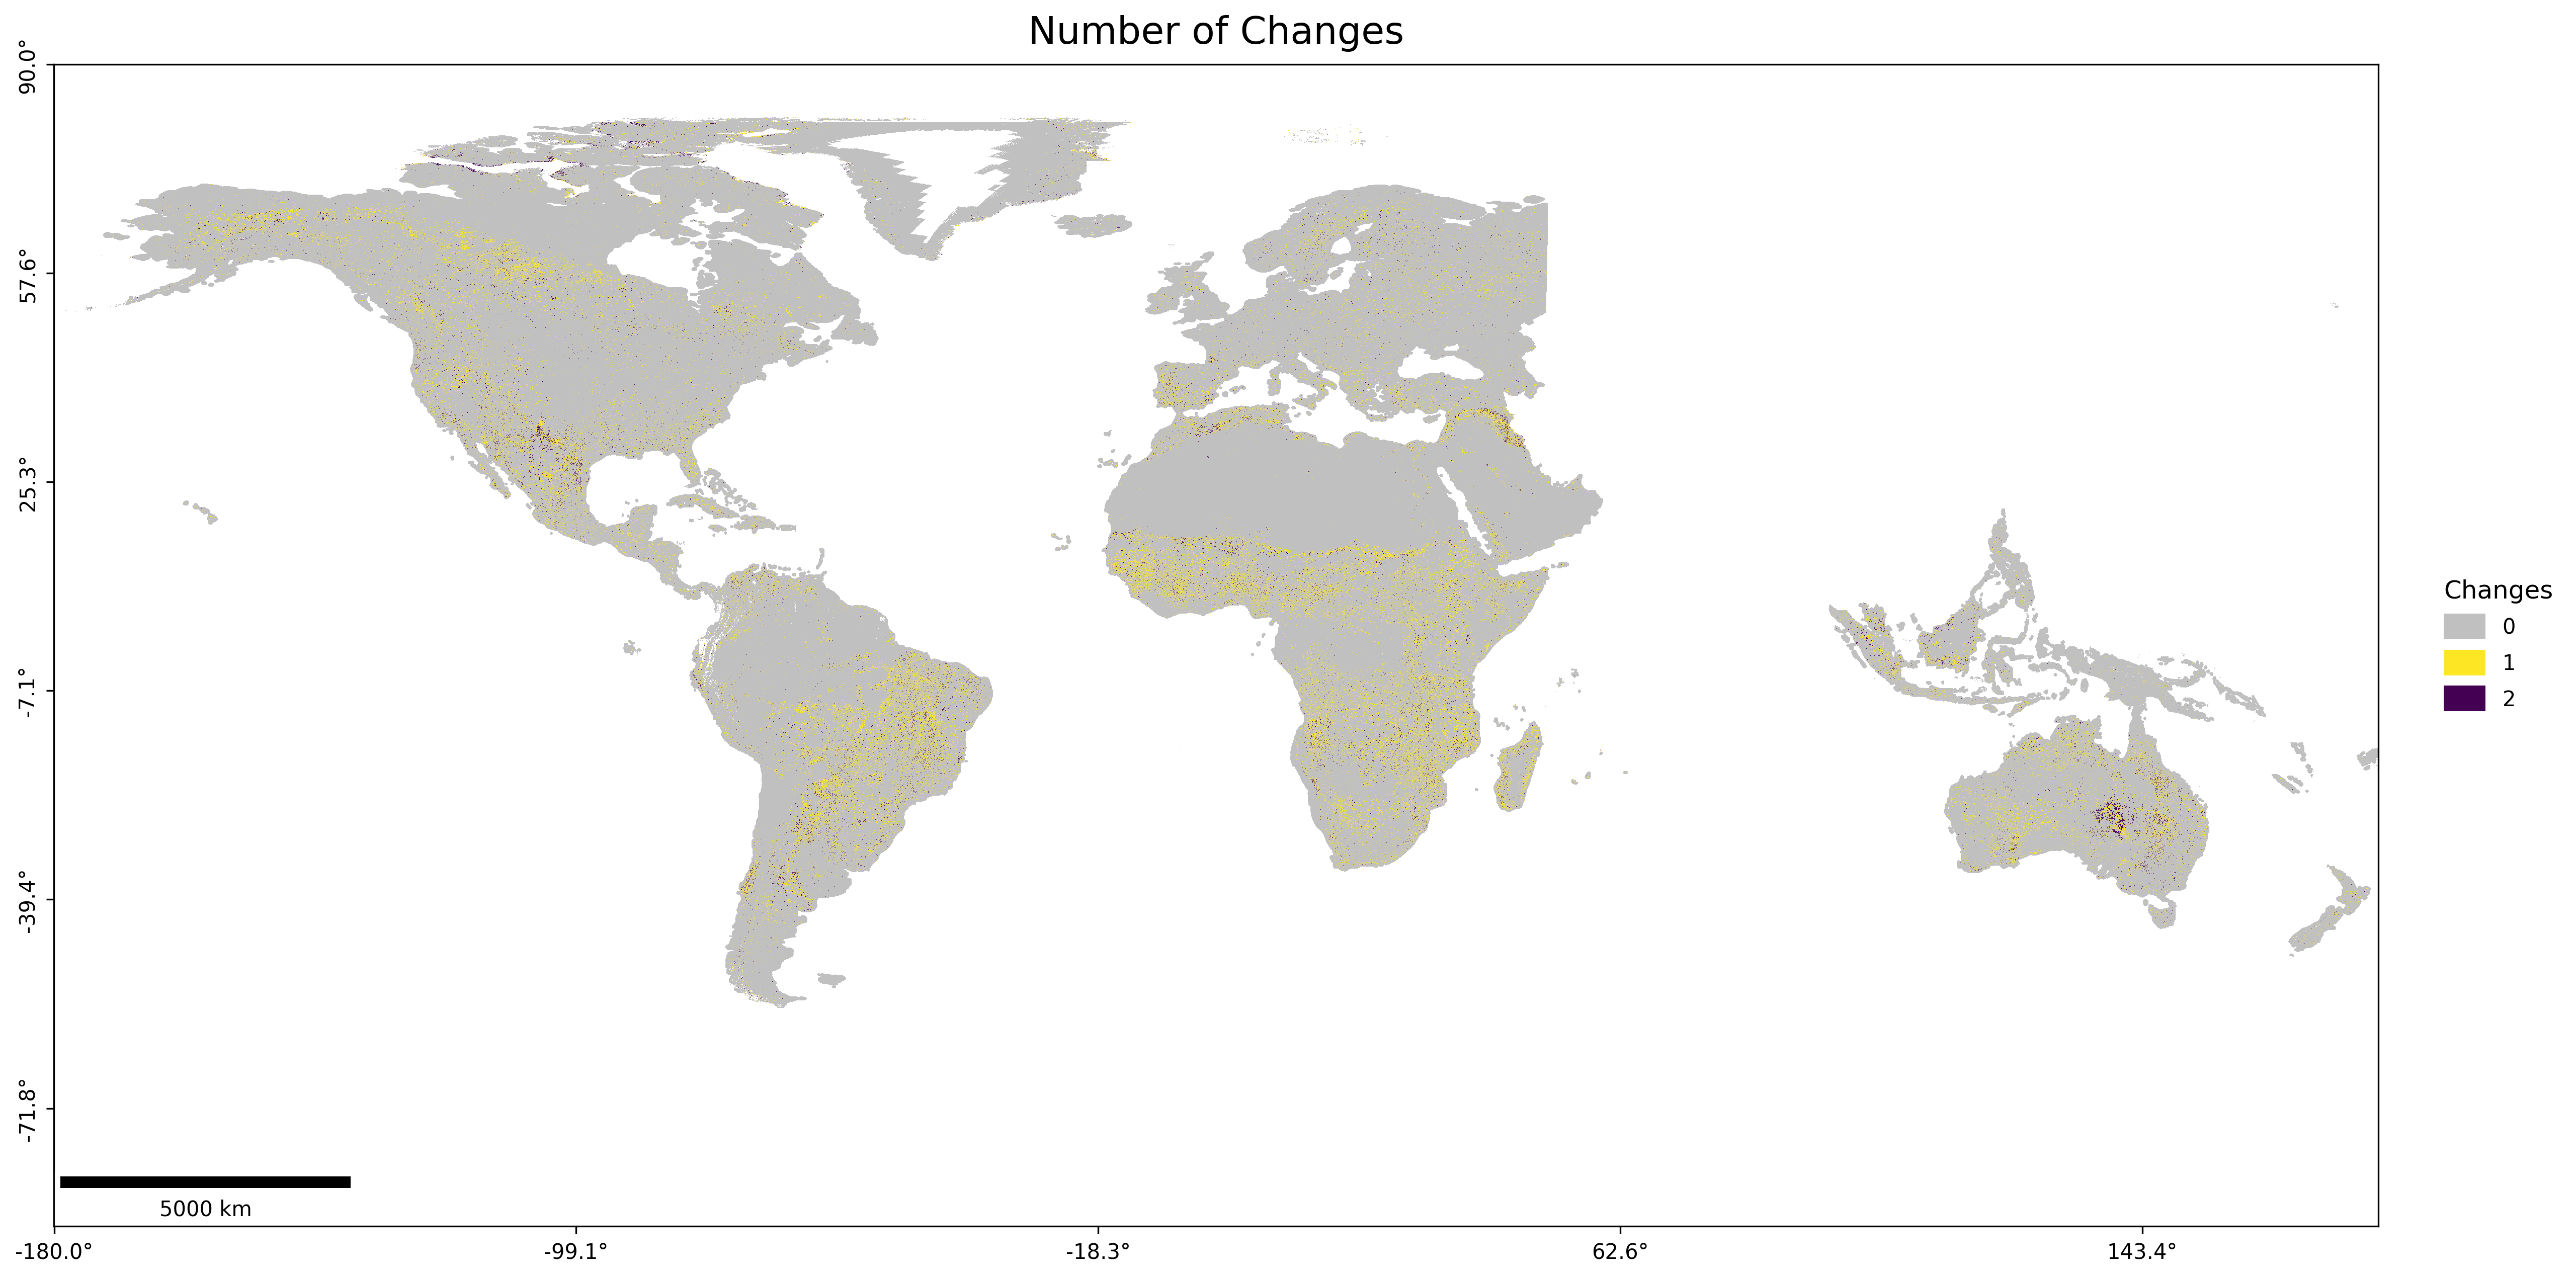

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/maps/map_number_of_changes.png


In [ ]:
# Execute the plotting function reading directly from the Drive folder
print("Generating the global Number of Changes map from GEE rasters...")

try:
    utils.plot_number_of_changes_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename="Number_of_Changes_Raster",
        scale_factor=0.05
    )
except Exception as e:
    print(f"\nError running the function: {e}")

#5.Trajectory Analysis

## 5.1 Export Trajectory raster map taks to GEE

In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# 1. Execute the trajectory analysis task utilizing the global variables
trajectory_task = utils.export_trajectory_task_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=300,
    collection_id=utils.GLANCE_COLLECTION_ID,
    band_name=utils.GLANCE_CLASS_BAND,
    nodata_val=utils.NODATA_VALUE,
)

Task 'Trajectory_Analysis_2001_2019' submitted to Google Earth Engine.


## 5.2 Export compute Trajectories per Time Interval task to GEE

In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the new GEE task
trajectory_intervals_task = utils.export_trajectory_intervals_csv_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=300,
)

Task 'Trajectory_Contributions_2001_2019' submitted to Google Earth Engine.


## 5.3 Plot Trajectory per Time Interval

Loading data from: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/Trajectory_Contributions_2001_2019.csv


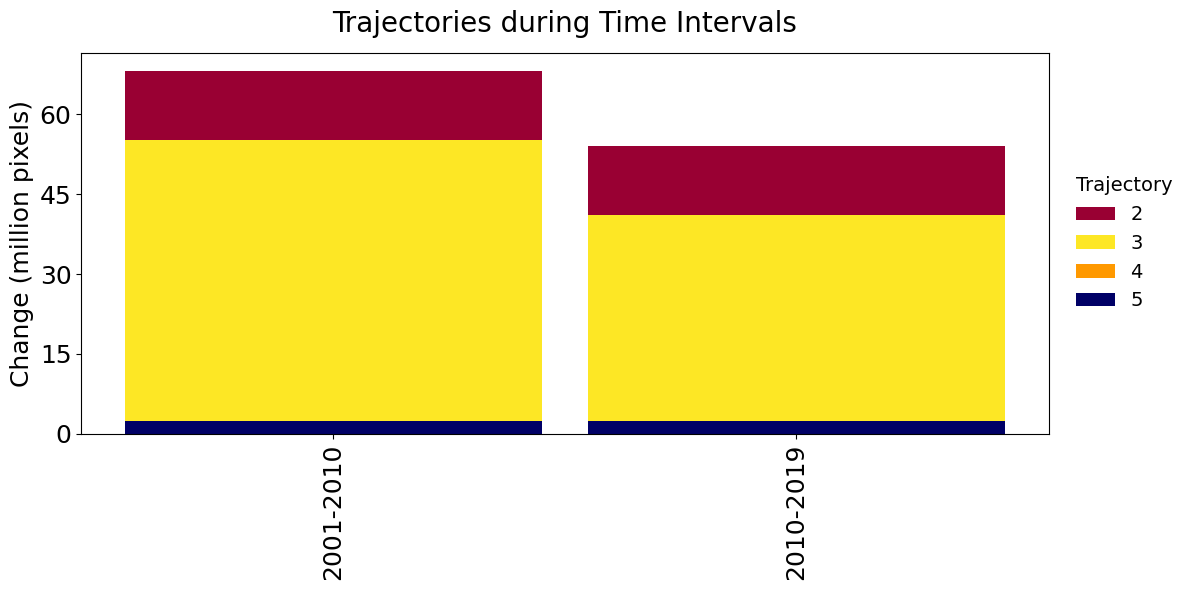

Figure saved to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/graphic_trajectory_time_interval.png


In [ ]:
import os
import pandas as pd
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# 1. Load the CSV exported by the GEE task from Drive
csv_filename = f"Trajectory_Contributions_{years_to_process[0]}_{years_to_process[-1]}.csv"
csv_path = os.path.join(base_drive_dir, csv_filename)

print(f"Loading data from: {csv_path}")

try:
    df_trajectory_intervals = pd.read_csv(csv_path, index_col="Interval")

    # Keep only the relevant trajectory columns (ignore system index or .geo if exported by GEE)
    valid_cols = [col for col in df_trajectory_intervals.columns if col in ['2', '3', '4', '5']]
    df_trajectory_intervals = df_trajectory_intervals[valid_cols]

    # 2. Execute the visualization using the utility function
    utils.plot_trajectory_contributions(
        df=df_trajectory_intervals,
        output_path=base_drive_dir,
    )
except FileNotFoundError:
    print(f"Error: The file {csv_filename} was not found.")
    print("Please ensure the GEE Export Task has finished running before executing this cell.")

## 5.x Export compute Trajectory overall task to GEE

In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the new GEE task for overall trajectory
trajectory_overall_task = utils.export_trajectory_overall_csv_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=300,
)

Task 'Trajectory_Overall_2001_2019' submitted to Google Earth Engine.


## 5.4 Plot Trajectory Overall chart

Reading total area from: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/Pixel_Counts_LULC_2001.csv
-> Total valid pixels (ignoring 255): 1,597,158,445

Generating the overall trajectory distribution chart...


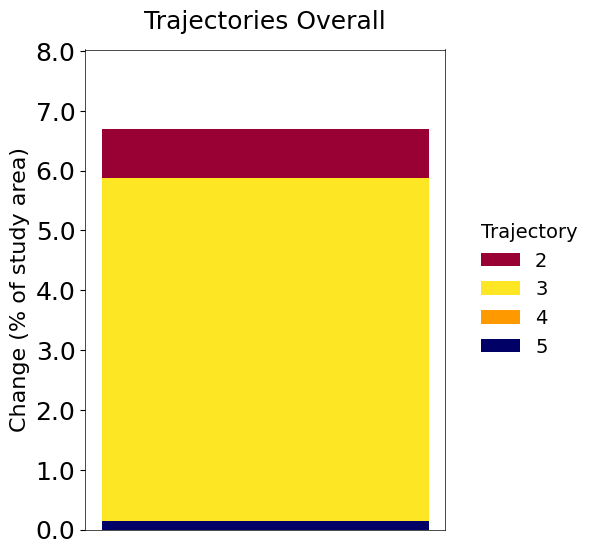

Figure saved to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/graphic_trajectory_percentage_overall.png


In [ ]:
import os
import pandas as pd
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# 1. Discover the total valid area using the pixel count from the initial year
y_start = years_to_process[0]
y_end = years_to_process[-1]
lulc_csv_path = os.path.join(base_drive_dir, f"Pixel_Counts_LULC_{y_start}.csv")

total_valid_pixels = 0
if os.path.exists(lulc_csv_path):
    print(f"Reading total area from: {lulc_csv_path}")
    df_lulc = pd.read_csv(lulc_csv_path)

    # Ignore metadata columns and class 255 (NoData)
    cols_to_ignore = ['system:index', '.geo', 'Period', '255']
    valid_cols = [c for c in df_lulc.columns if c not in cols_to_ignore]

    # Sum the pixels for all valid classes
    total_valid_pixels = df_lulc[valid_cols].sum().sum()
    print(f"-> Total valid pixels (ignoring 255): {total_valid_pixels:,.0f}")
else:
    print(f"Warning: File {lulc_csv_path} not found.")
    print("Cannot calculate the percentage over the total area.")

# 2. Generate the chart with the correct total area
overall_csv_filename = f"Trajectory_Overall_{y_start}_{y_end}.csv"

if total_valid_pixels > 0:
    print("\nGenerating the overall trajectory distribution chart...")
    utils.plot_trajectory_distribution(
        input_dir=base_drive_dir,
        csv_filename=overall_csv_filename,
        total_pixels=total_valid_pixels
    )


In [ ]:
import inspect
import utils

# Inspecionando a função plot_trajectory_distribution para verificar a formatação do eixo Y
try:
    source_code = inspect.getsource(utils.plot_trajectory_distribution)
    print(source_code)
except Exception as e:
    print(f"Erro ao inspecionar: {e}")

def plot_trajectory_distribution(
    input_dir: str,
    csv_filename: str,
    total_pixels: float = None,
) -> None:
    """
    Generate and save a stacked bar chart of trajectory class distributions.

    Reads trajectory pixel counts from an exported GEE CSV file and 
    calculates percentages. If total_pixels is provided, it calculates
    the percentage relative to the entire study area.

    Parameters
    ----------
    input_dir : str
        Directory path containing the input CSV and for output charts.
    csv_filename : str
        Name of the CSV file containing overall trajectory counts.
    total_pixels : float, optional
        Total number of valid pixels in the study area, by default None.

    Returns
    -------
    None
        The function saves the plot to disk and displays it.

    Raises
    ------
    FileNotFoundError
        If the specified CSV file is not found.
    """
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    import

## 5.5 Plot Trajectory Map

Generating the global Trajectory map from GEE rasters...


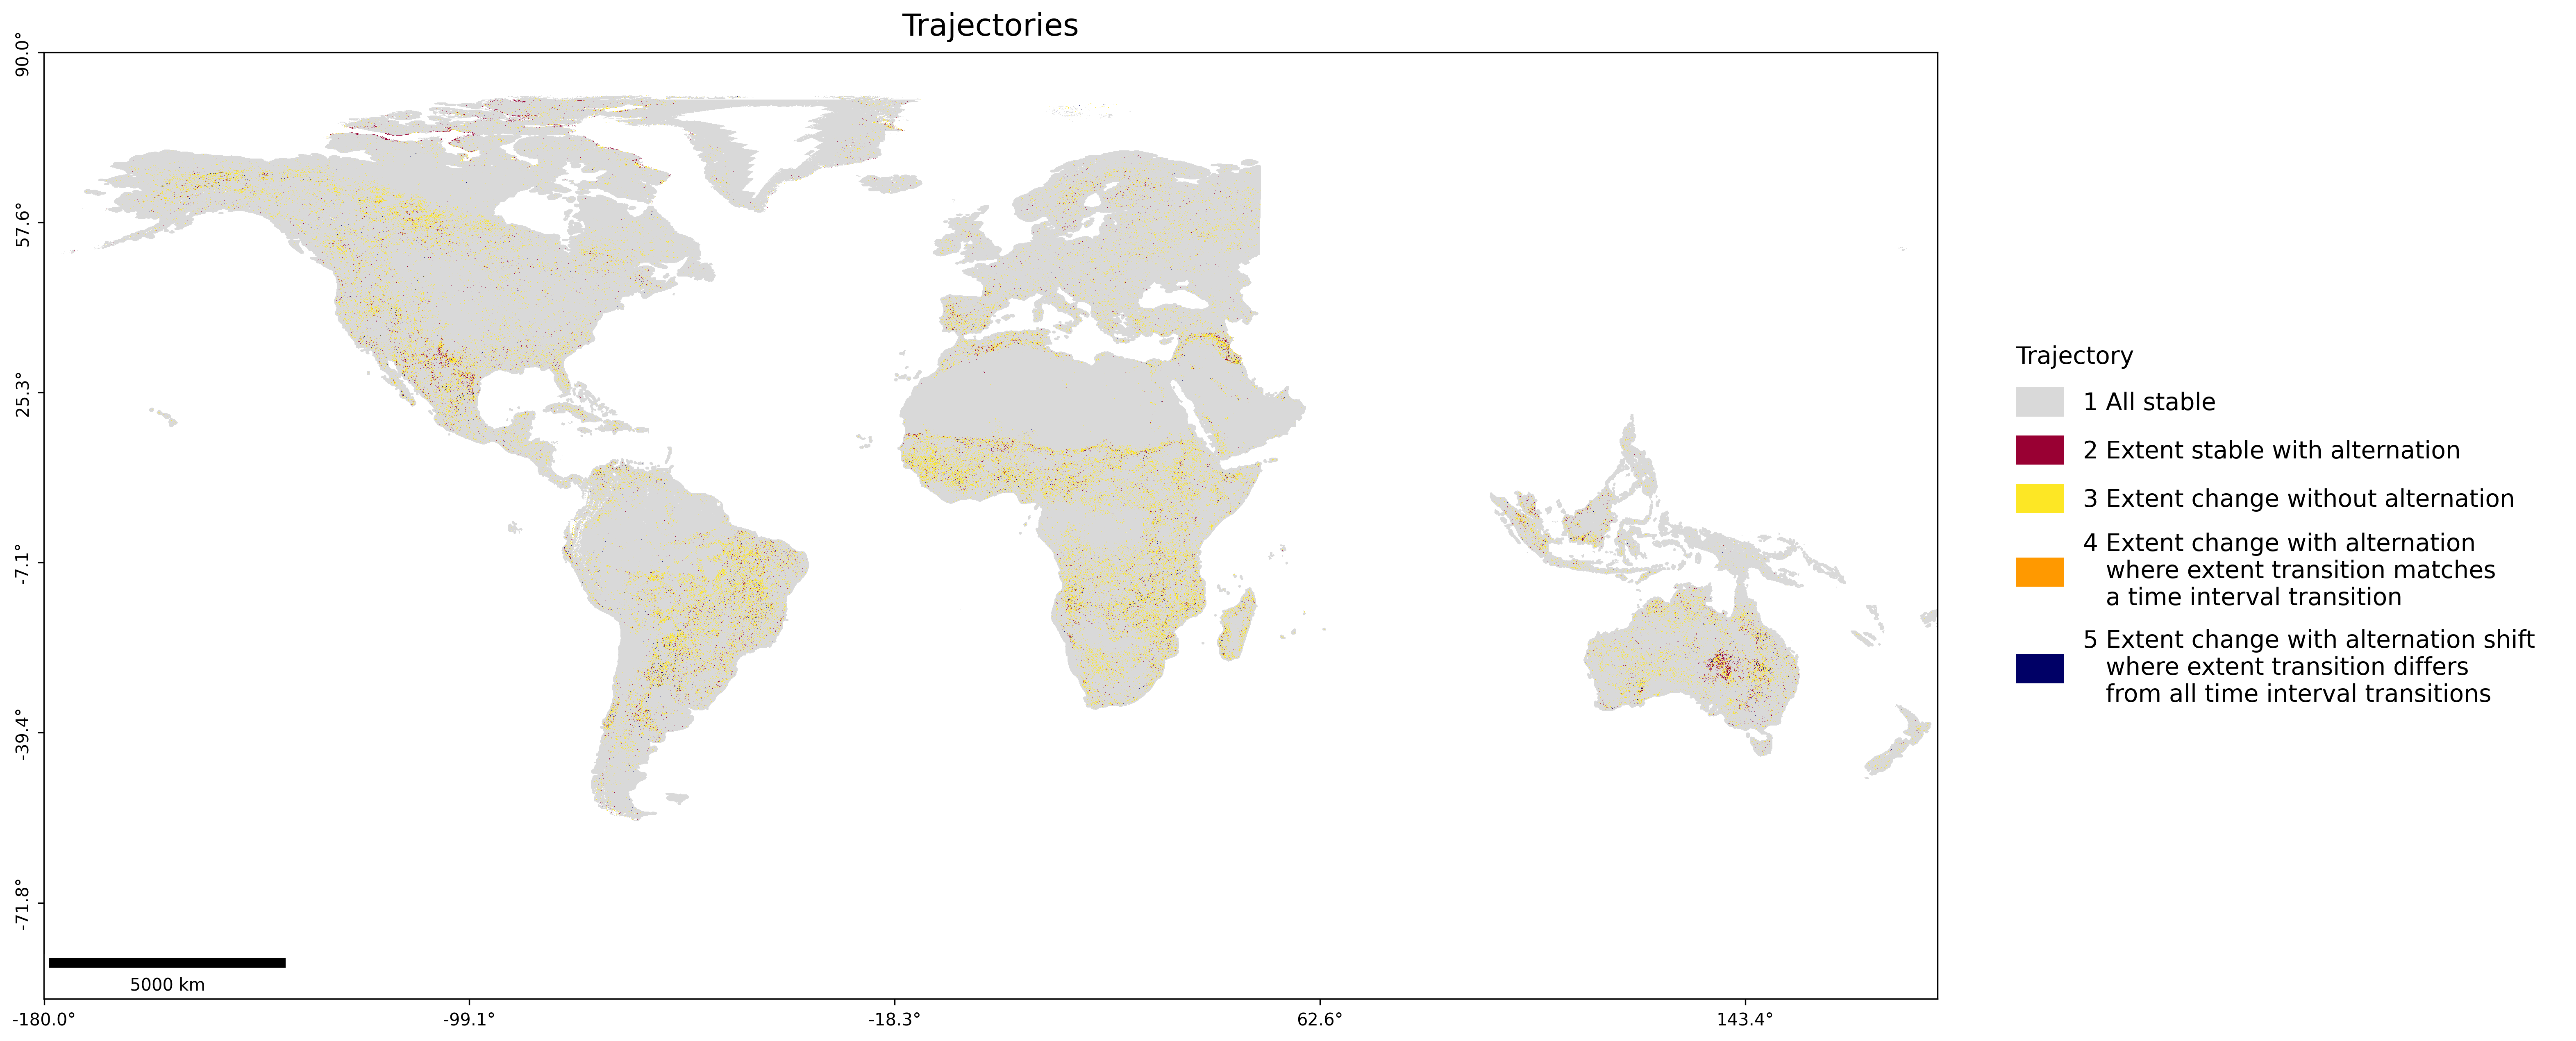

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/maps/map_trajectories.png


In [ ]:
import os
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function using the updated parameters
print("Generating the global Trajectory map from GEE rasters...")
utils.plot_trajectory_map(
    output_dir=base_drive_dir,
    vrt_filename="merged_trajectory.vrt",
    scale_factor=0.05,
    nodata_val=255
)


# 6.Change Components Analysis

## 6.1 Compute Transition matrix

In [ ]:
import importlib
import utils

# Reload utils safely
importlib.reload(utils)

print("Submitting interval transition matrix tasks to GEE...")

# Using the native and already tested function from utils.py
transition_tasks = utils.export_global_transition_tasks(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=300
)

print(f"\nSuccess! Submitted {len(transition_tasks)} tasks to GEE. You can check the progress in the Earth Engine Tasks tab.")


Submitting interval transition matrix tasks to GEE...
Task started for transition_2001_2010 (Scale: 300m)
Task started for transition_2010_2019 (Scale: 300m)
Task started for transition_2001_2019 (Scale: 300m)

Success! Submitted 3 tasks to GEE. You can check the progress in the Earth Engine Tasks tab.


## 6.2 Compute Aggregation matrices

In [22]:
import importlib
import utils

# Reload utils to ensure the latest refactored functions are available
importlib.reload(utils)

print("Calculating aggregated components algebraically from GEE CSVs...")

# 1. Execute the clean refactored function from utils
utils.calculate_aggregated_components_csv(
    year_list=years_to_process,
    input_dir=base_drive_dir,
    output_dir=base_drive_dir
)

print("\nReloading matrices...")
# 2. Reload the verified matrices dictionaries
matrices = utils.load_and_reorder_matrices(
    output_path=base_drive_dir,
    interval_str=interval_str
)
print(f"\nSuccess! {len(matrices)} matrices loaded and reordered.")

Calculating aggregated components algebraically from GEE CSVs...
Computing Sum Matrix from GEE pixel transitions...
Loading Extent Matrix...
Saved sum matrix: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/transition_matrix_sum_2001-2019.csv
Saved extent matrix: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/transition_matrix_extent_2001-2019.csv
Saved allocation_exchange matrix: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/transition_matrix_allocation_exchange_2001-2019.csv
Saved quantity_allocation_shift matrix: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/transition_matrix_quantity_allocation_shift_2001-2019.csv
Saved alternation_exchange matrix: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/transition_matrix_alternation_exchange_2001-2019.csv
Saved alternation_shift matrix: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/transition_matrix_alternation_shift_2001-2019.csv
Saved unaccounted_extent matrix: /content/drive/MyDrive/GLANCE_Glob

## 6.3 Compute Components of Change

In [23]:
import importlib
import utils

# Reload utils to ensure the latest refactored functions are available
importlib.reload(utils)

print("Generating change components summary table...")

# Execute the refactored function using global parameters
utils.generate_change_components_table(
    year_list=years_to_process,
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
    class_labels_dict=utils.GLANCE_METADATA
)

Generating change components summary table...


Processing aggregated matrices: 100%|██████████| 4/4 [00:00<00:00, 109.23it/s]



Success! Final components saved to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/tables/change_components.csv


## 6.4 Heat Maps

### 6.4.1 Input Setup and Interity Checks

In [39]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the validation and interval extraction using global variables
try:
    interval_str = utils.validate_and_get_interval(
        years=years_to_process,
        output_path=base_drive_dir,
        class_labels_dict=utils.GLANCE_METADATA
    )
    print(f"Validation successful! Interval string: {interval_str}")
except ValueError as e:
    print(f"Validation Error: {e}")

Validation successful! Interval string: 2001-2019


### 6.4.2 Data Transformation and Matrix Alignment

In [40]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Load and reorder matrices using the refactored function
try:
    matrices = utils.load_and_reorder_matrices(
        output_path=base_drive_dir,
        interval_str=interval_str
    )
    print(f"Success! {len(matrices)} matrices loaded and reordered.")
except Exception as e:
    print(f"Error loading matrices: {e}")

Success! 7 matrices loaded and reordered.


### 6.4.3 Plot heat Maps

Generating Heatmaps...


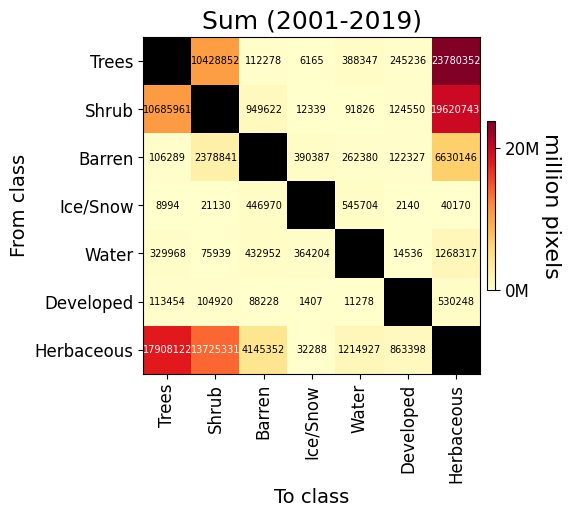

-> Saved heatmap: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/heatmap_sum_2001-2019.png


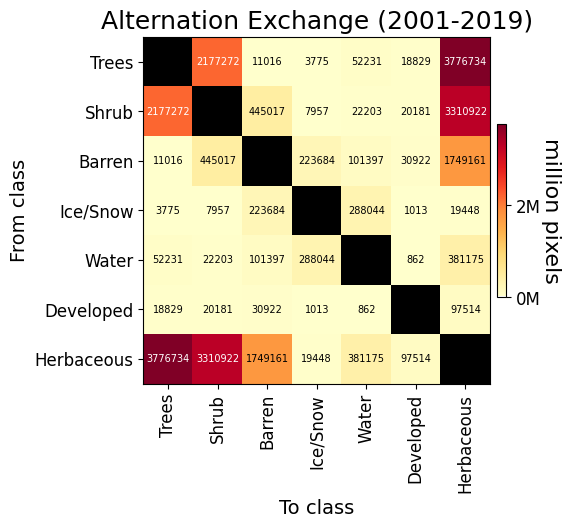

-> Saved heatmap: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/heatmap_alt_exc_2001-2019.png


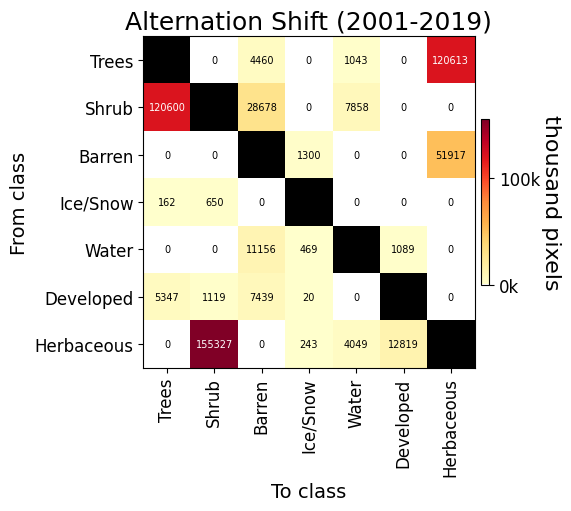

-> Saved heatmap: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/heatmap_alt_shift_2001-2019.png


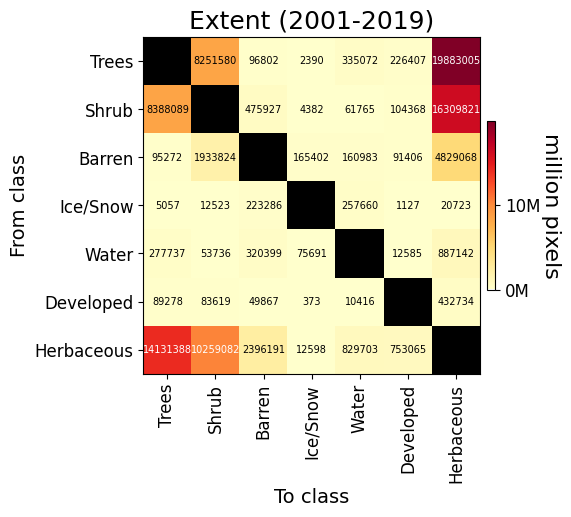

-> Saved heatmap: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/heatmap_ext_2001-2019.png


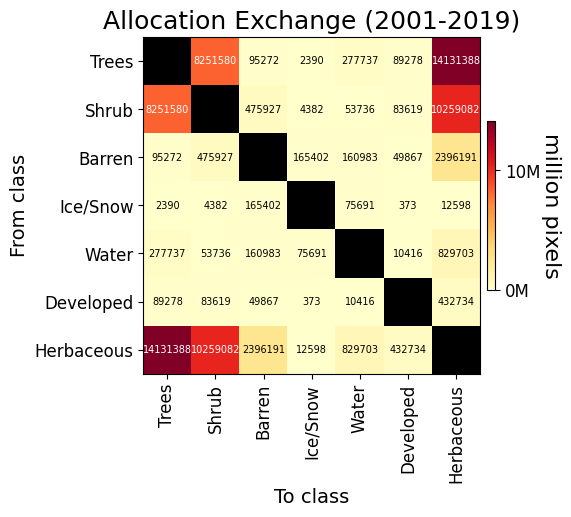

-> Saved heatmap: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/heatmap_all_exc_2001-2019.png


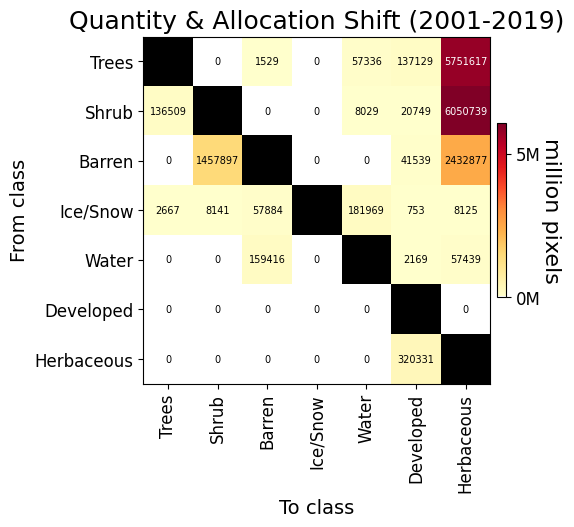

-> Saved heatmap: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/heatmap_qty_shift_2001-2019.png


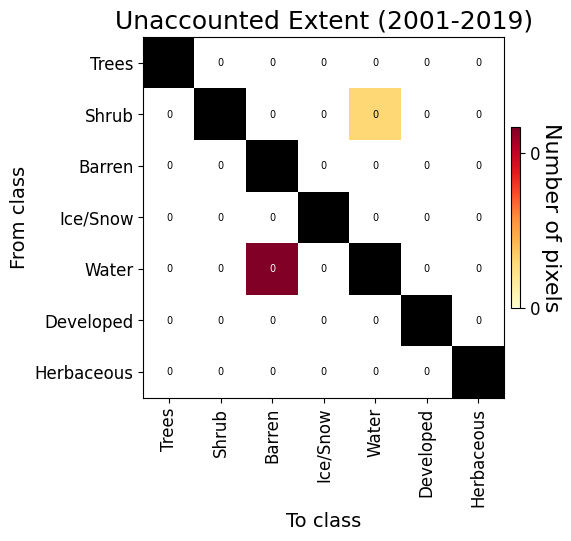

-> Saved heatmap: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/heatmap_unacc_ext_2001-2019.png


In [59]:
import importlib
import utils

importlib.reload(utils)

style_config = {
    "tick_fontsize_x": 12,
    "tick_fontsize_y": 12,
    "axis_label_fontsize": 14,
    "title_fontsize": 18,
    "ann_fontsize": 7,
    "cbar_fraction": 0.025,
    "cbar_pad": 0.02,
    "cbar_tick_labelsize": 12,
    "cbar_label_fontsize": 16,
    "cmap": "YlOrRd",
    "cell_size_inch": 0.8,
}

utils.generate_all_heatmaps(
    matrices_dict=matrices,
    output_path=base_drive_dir,
    interval_str=interval_str,
    years=years_to_process,
    style_config=style_config
)

## 6.5 Charts

### 6.5.1 Plot QUEST during Time Intervals chart

Generating change components during time intervals chart...


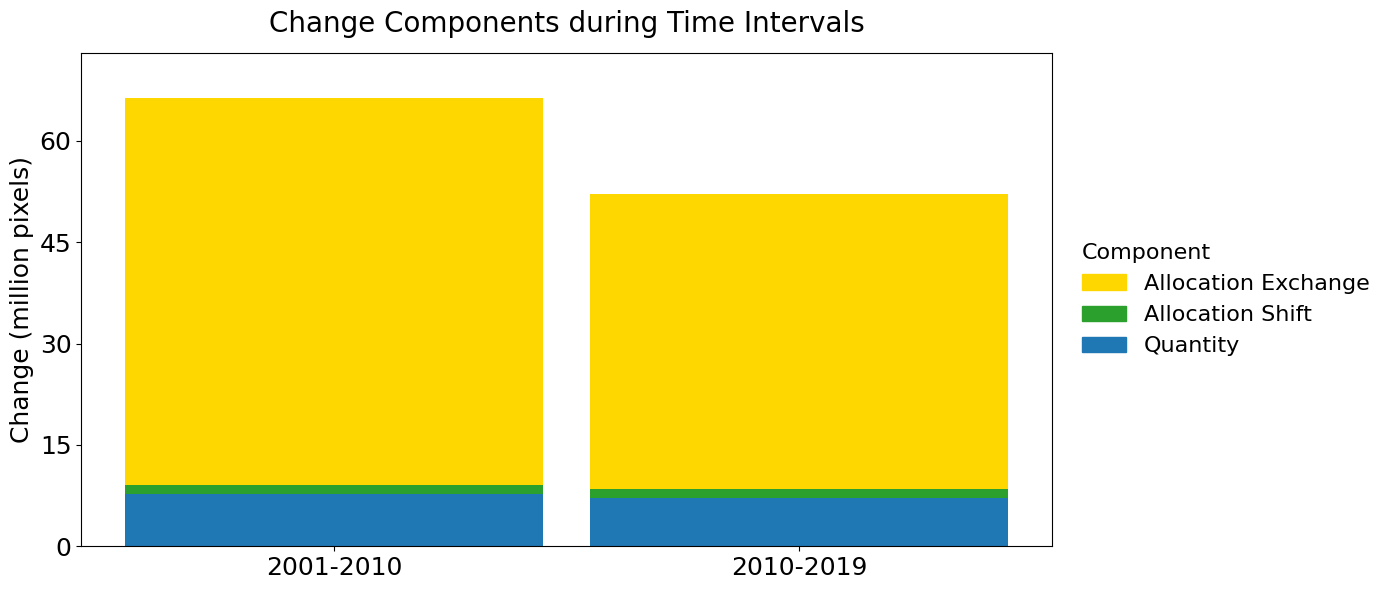

Chart saved to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/chart_change_components_time_interval.png


In [38]:
import importlib
import utils

# Reload utils to ensure the latest refactored functions are available
importlib.reload(utils)

print("Generating change components during time intervals chart...")

# Execute the plotting function
utils.plot_change_components_time_intervals(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
)

### 6.5.2 Plot QUEST Overall chart

Generating overall change components chart...


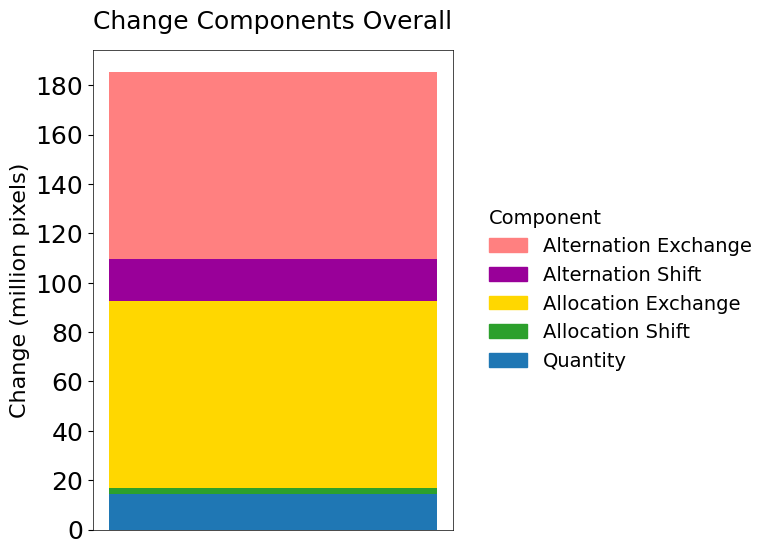

Chart saved to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/graphic_change_components_overall.png


In [ ]:
import os
import importlib
import utils

# Reload utils to ensure the latest refactored functions are available
importlib.reload(utils)

print("Generating overall change components chart...")

# Specify paths and execute the plotting function
csv_components_path = os.path.join(
    base_drive_dir,
    "tables",
    "change_components.csv",
)

utils.plot_components_with_alternation(
    csv_path=csv_components_path,
    output_path=base_drive_dir,
)


### 6.5.3 Plot QUEST by Class chart

Generating change components by class chart...


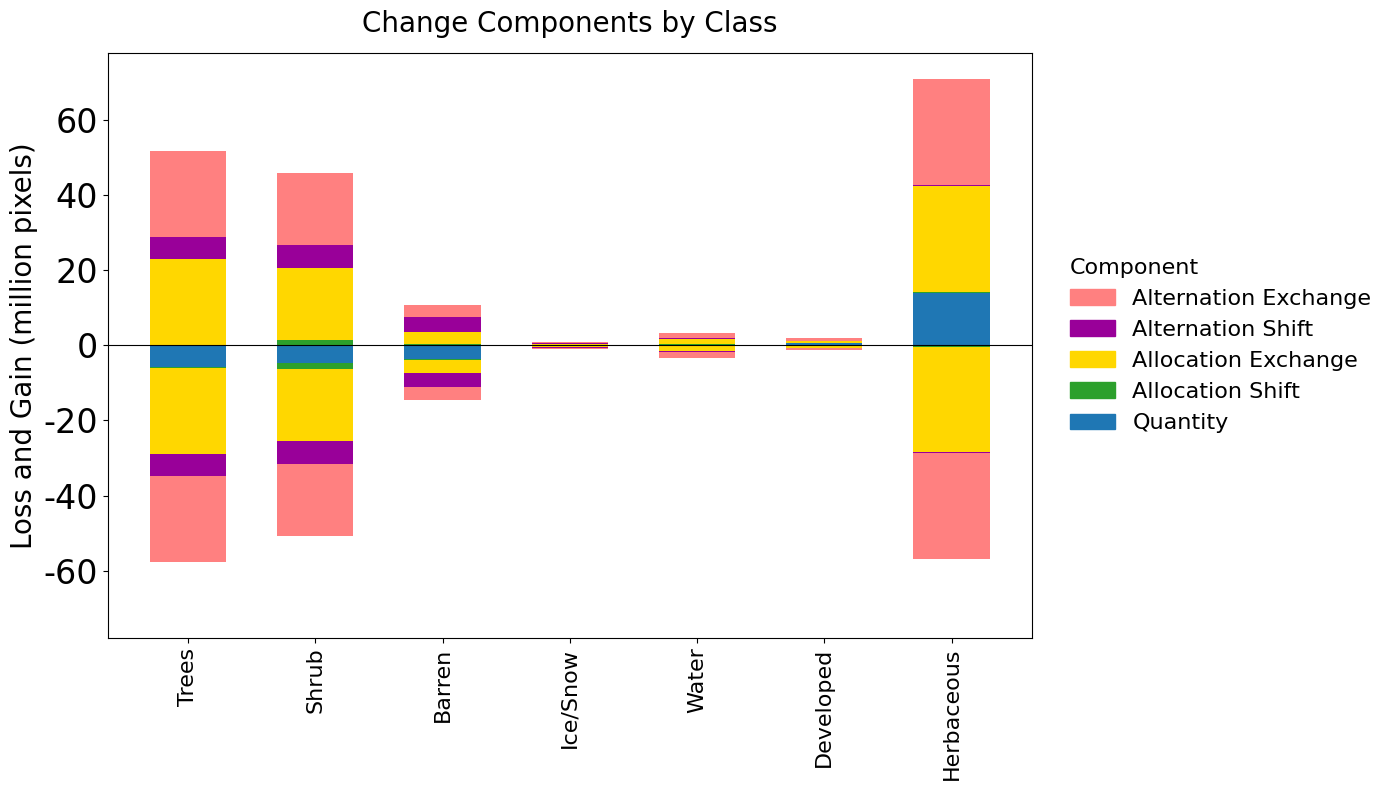

Chart saved to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/charts/chart_change_component_change_class.png


In [ ]:
import importlib
import utils

# Reload utils to ensure the latest refactored functions are available
importlib.reload(utils)

print("Generating change components by class chart...")

# Execute the plotting function
utils.plot_change_components_by_class(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
    class_labels_dict=utils.GLANCE_METADATA
)


## 6.6 Maps

### 6.6.1 Export compute Extent map task to GEE

In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function using the global configuration variables
print("Submitting Quantity Component Raster Task to GEE...")
quantity_raster_task = utils.export_quantity_component_task_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=300,
    nodata_val=utils.NODATA_VALUE,
)
print("\nSuccess! You can monitor the progress in the GEE Tasks tab.")

Submitting Quantity Component Raster Task to GEE...
Task 'Quantity_Component_2001_2019' submitted to Google Earth Engine with NoData: 255

Success! You can monitor the progress in the GEE Tasks tab.


### 6.6.2 Plot Extent Change map

Generating the global Extent Change map from GEE rasters...


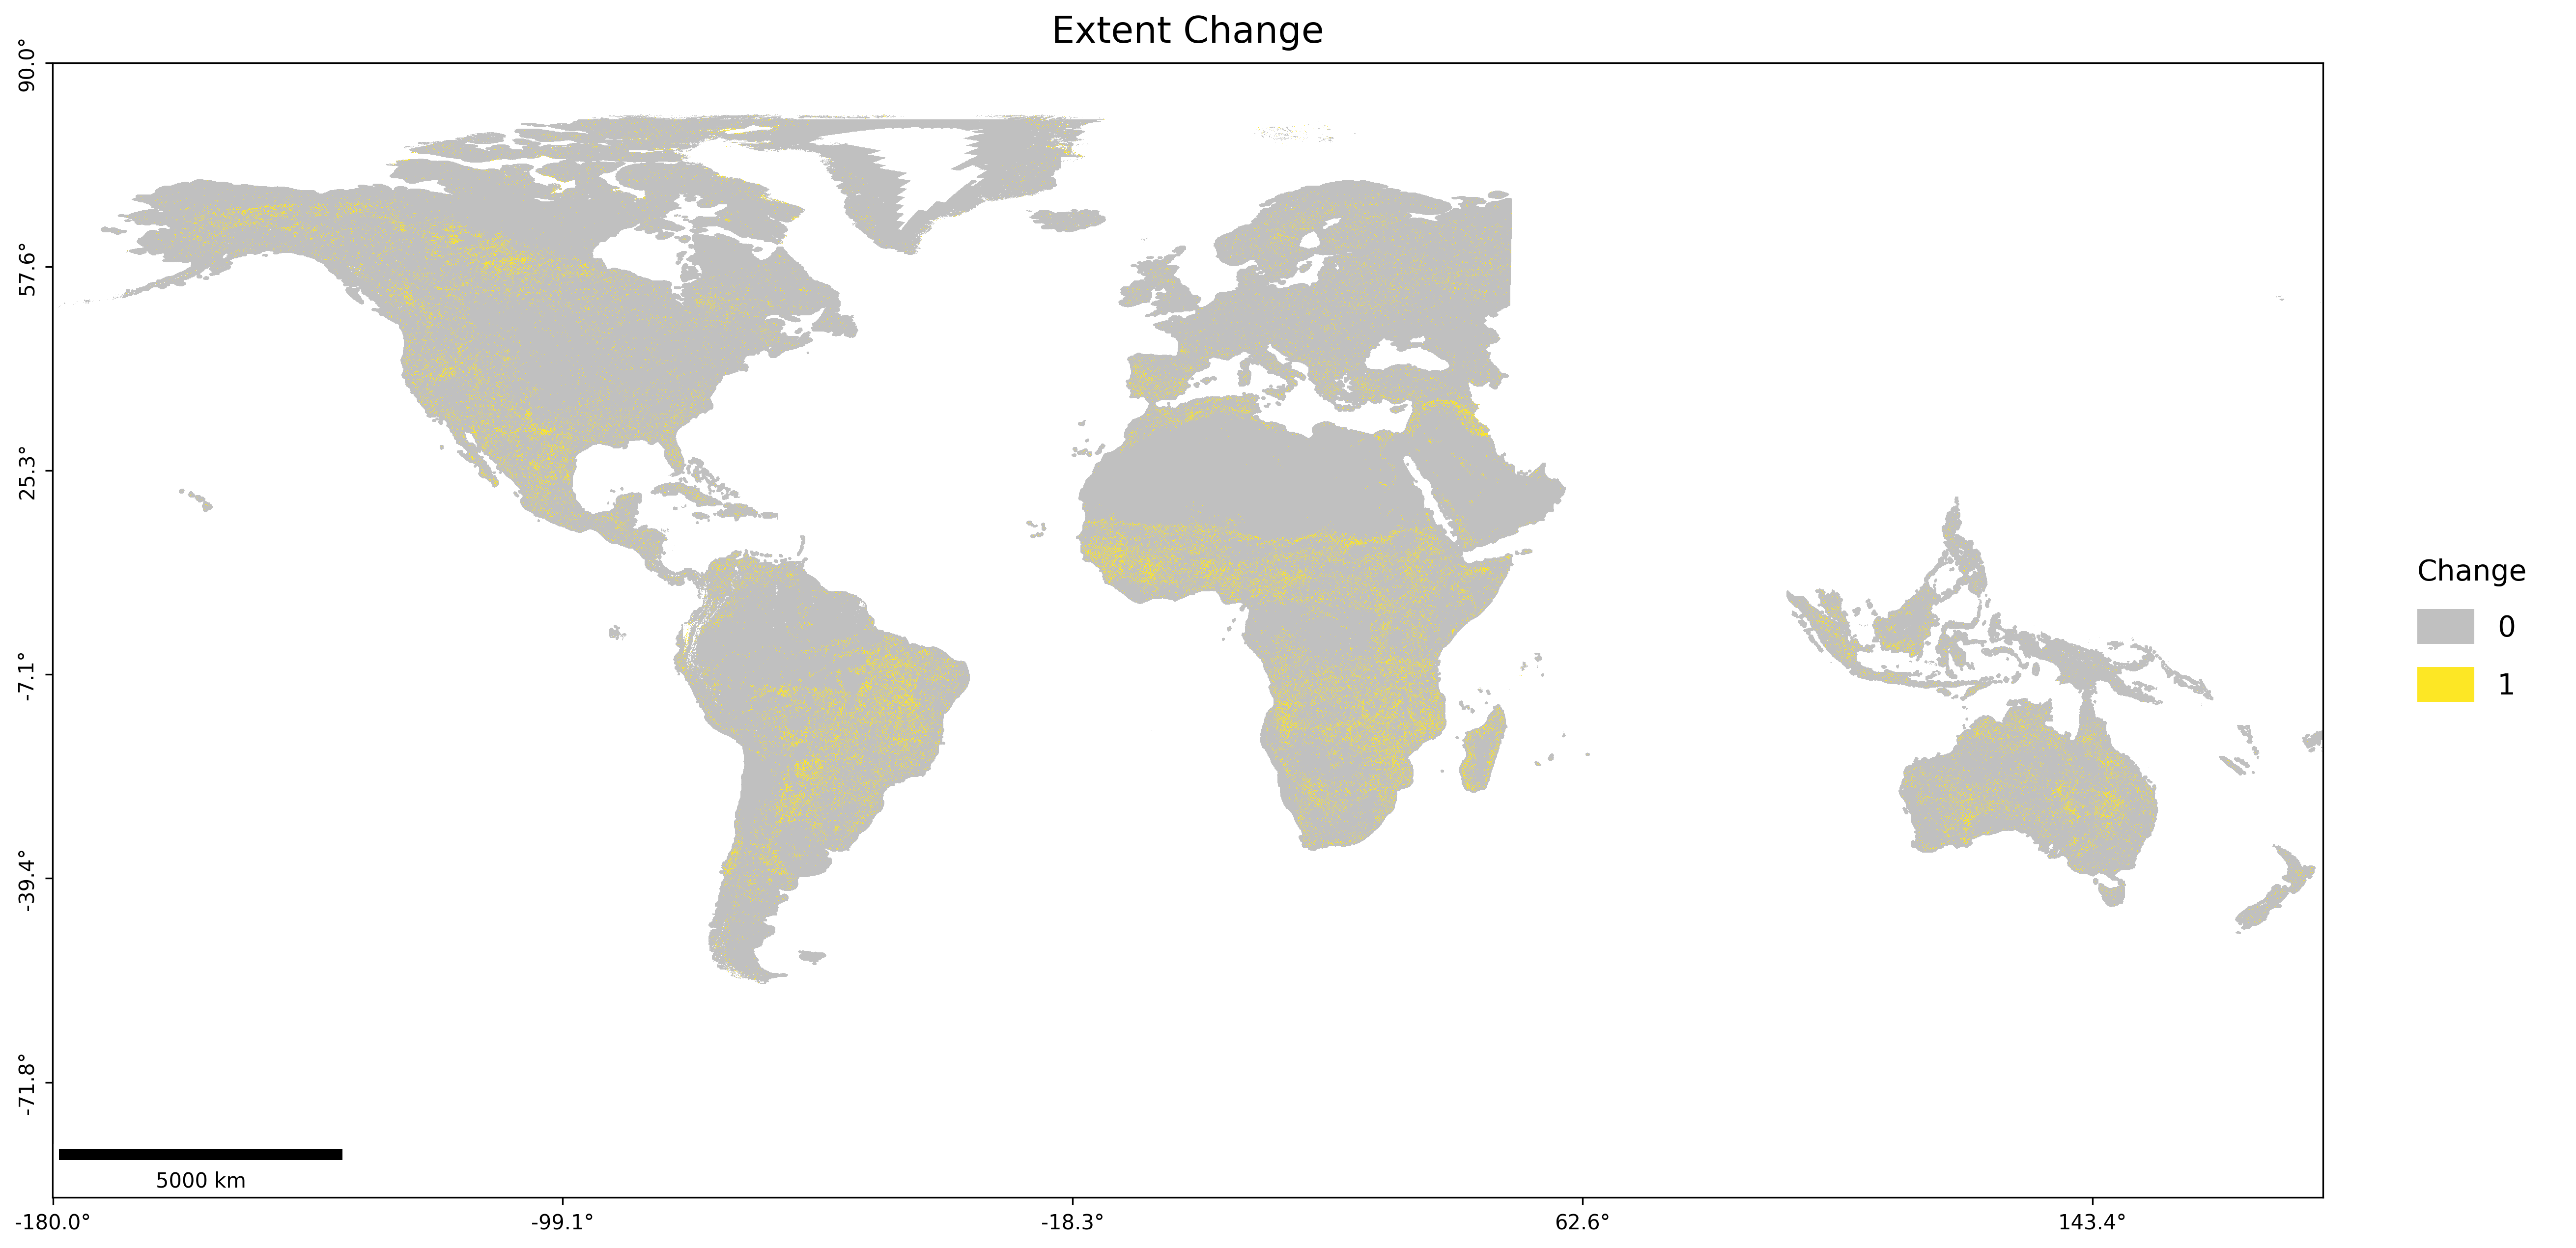

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/maps/map_extent_change.png


In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function
print("Generating the global Extent Change map from GEE rasters...")
raster_prefix = f"Quantity_Component_{years_to_process[0]}_{years_to_process[-1]}"

try:
    utils.plot_quantity_component_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename=raster_prefix,
        scale_factor=0.05,
    )
except Exception as e:
    print(f"\nError running the function: {e}")

### 6.6.3 Export compute Alternation Exchange task to GEE

In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function using the global configuration variables
print("Submitting Alternation Exchange Raster Task to GEE...")
exchange_raster_task = utils.export_alternation_exchange_task_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=300,
    nodata_val=utils.NODATA_VALUE,
)
print("\nSuccess! You can monitor the progress in the GEE Tasks tab.")

Submitting Alternation Exchange Raster Task to GEE...
Preparing Alternation Exchange GEE Task for 2001-2019...


Task 'Alternation_Exchange_2001_2019' submitted to Google Earth Engine with NoData: 255

Success! You can monitor the progress in the GEE Tasks tab.


###  6.6.4 Plot Alternation Exchange map

Generating the global Alternation Exchange map from GEE rasters...


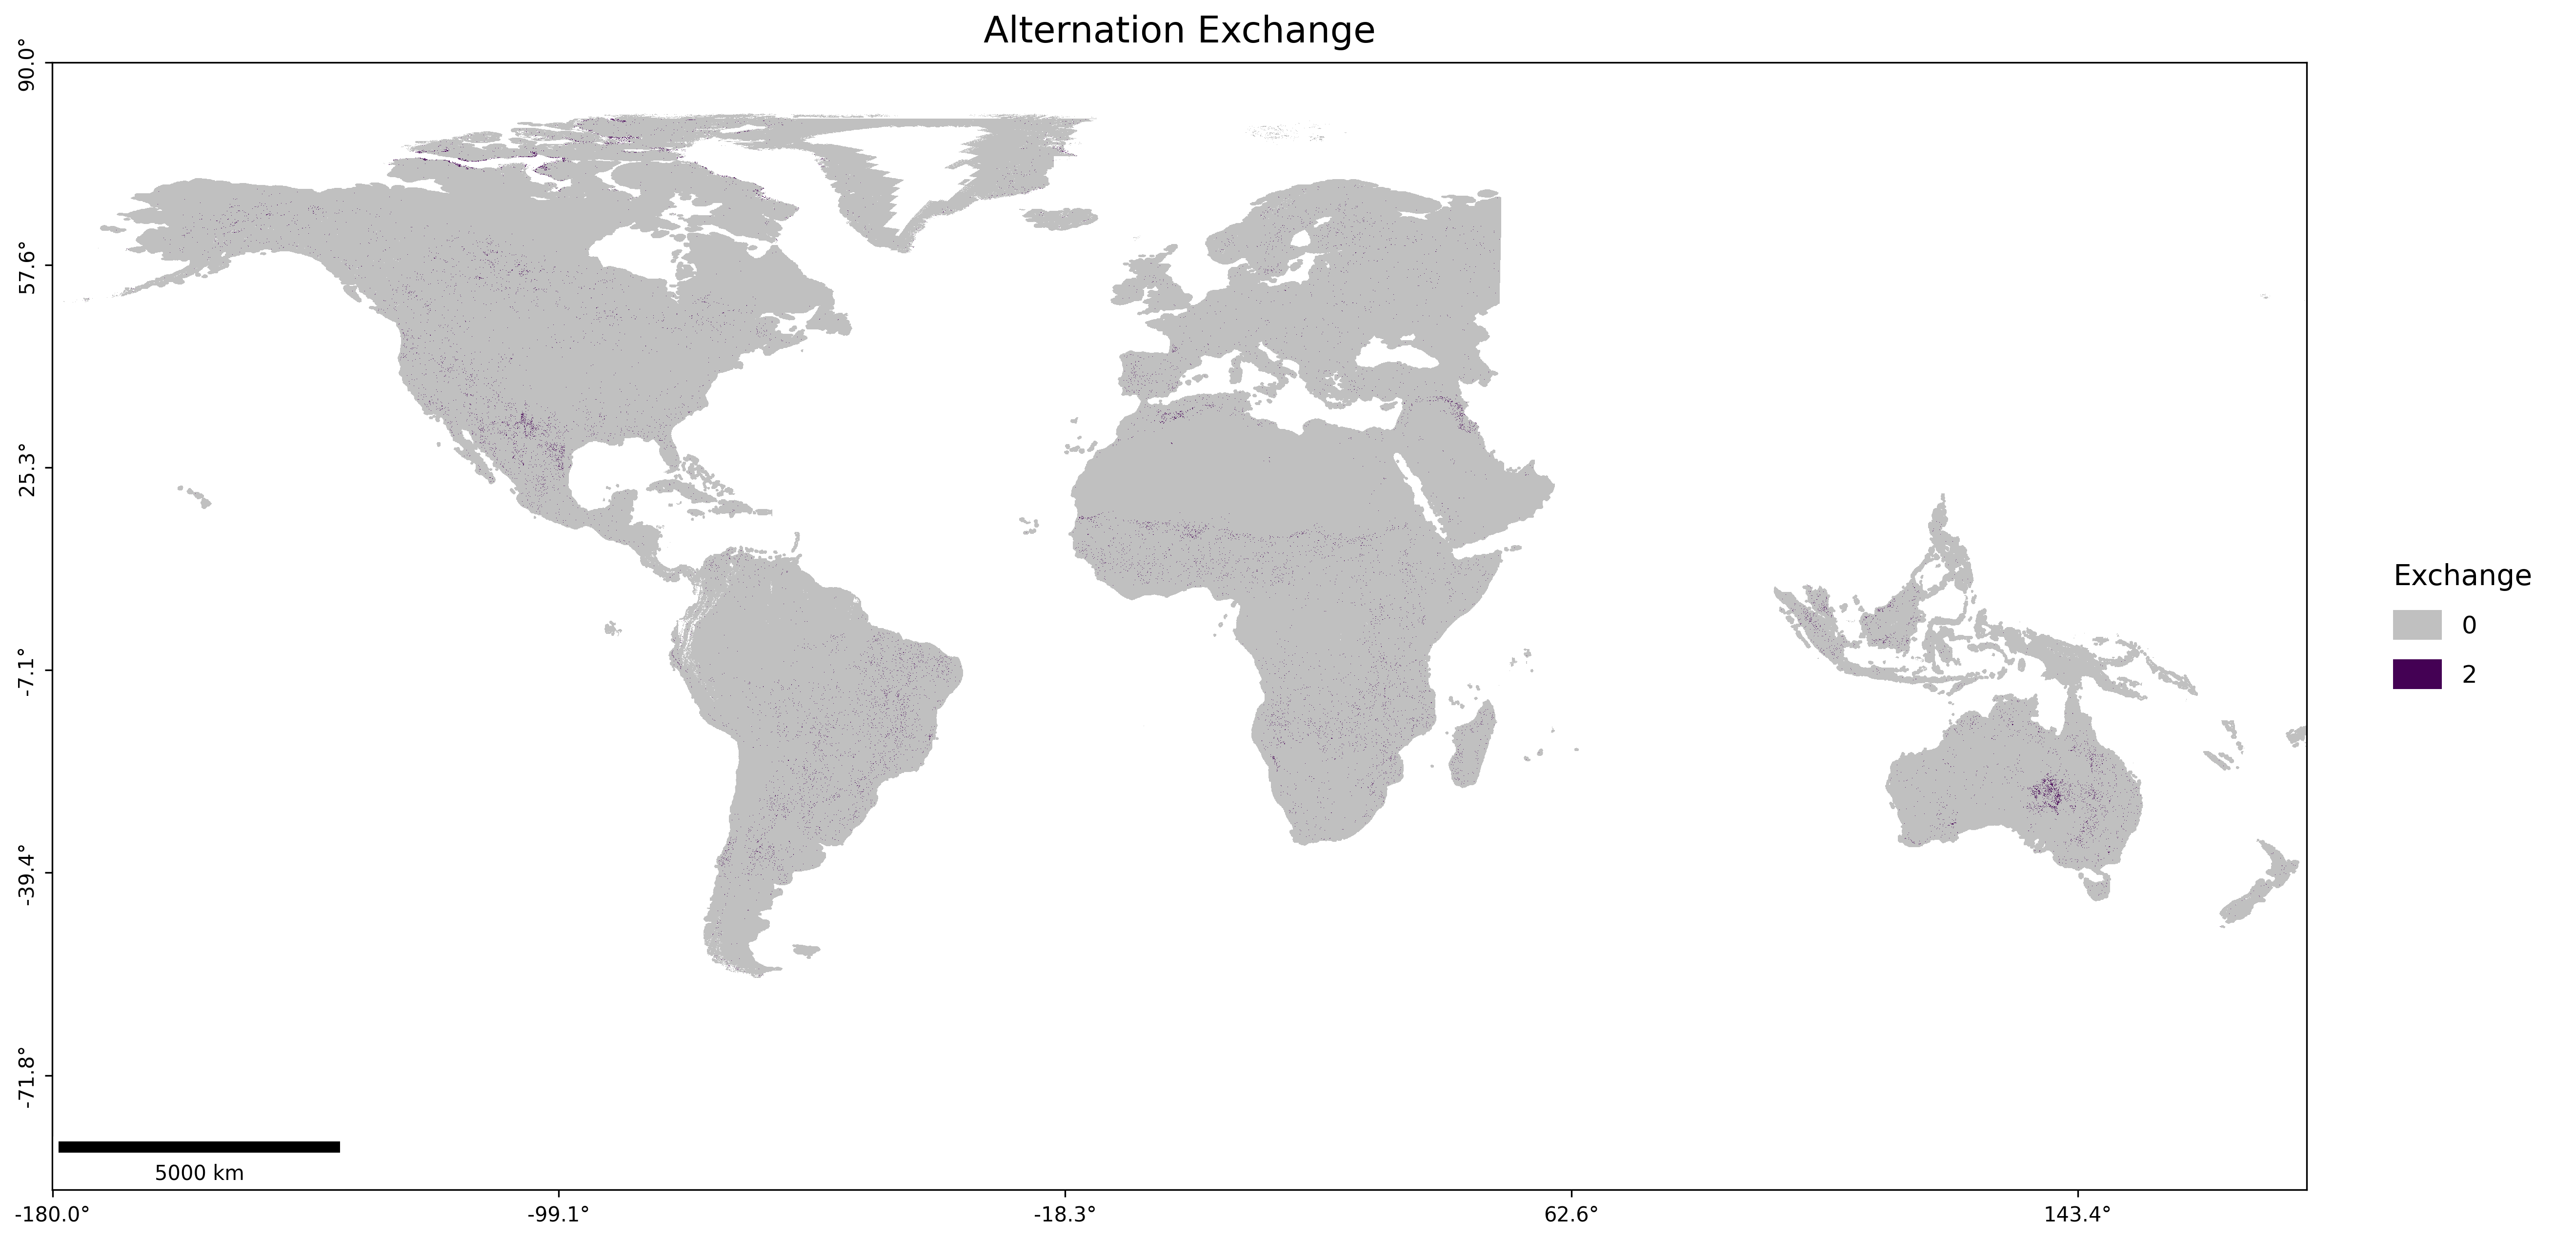

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/maps/map_alternation_exchange.png


In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function using the global configuration variables
print("Generating the global Alternation Exchange map from GEE rasters...")
raster_prefix = f"Alternation_Exchange_{years_to_process[0]}_{years_to_process[-1]}"

try:
    utils.plot_alternation_exchange_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename=raster_prefix,
        scale_factor=0.05,
    )
except Exception as e:
    print(f"\nError running the function: {e}")

### 6.6.5 Export compute Alternation Shift task to GEE

In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function using the global configuration variables
print("Submitting Alternation Shift Raster Task to GEE...")
shift_raster_task = utils.export_alternation_shift_task_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=300,
    nodata_val=utils.NODATA_VALUE,
)
print("\nSuccess! You can monitor the progress in the GEE Tasks tab.")

Submitting Alternation Shift Raster Task to GEE...
Preparing Alternation Shift GEE Task for 2001-2019...


Task 'Alternation_Shift_2001_2019' submitted to Google Earth Engine with NoData: 255

Success! You can monitor the progress in the GEE Tasks tab.


### 6.6.6 Plot Alternation Shift map

Generating the global Alternation Shift map from GEE rasters...


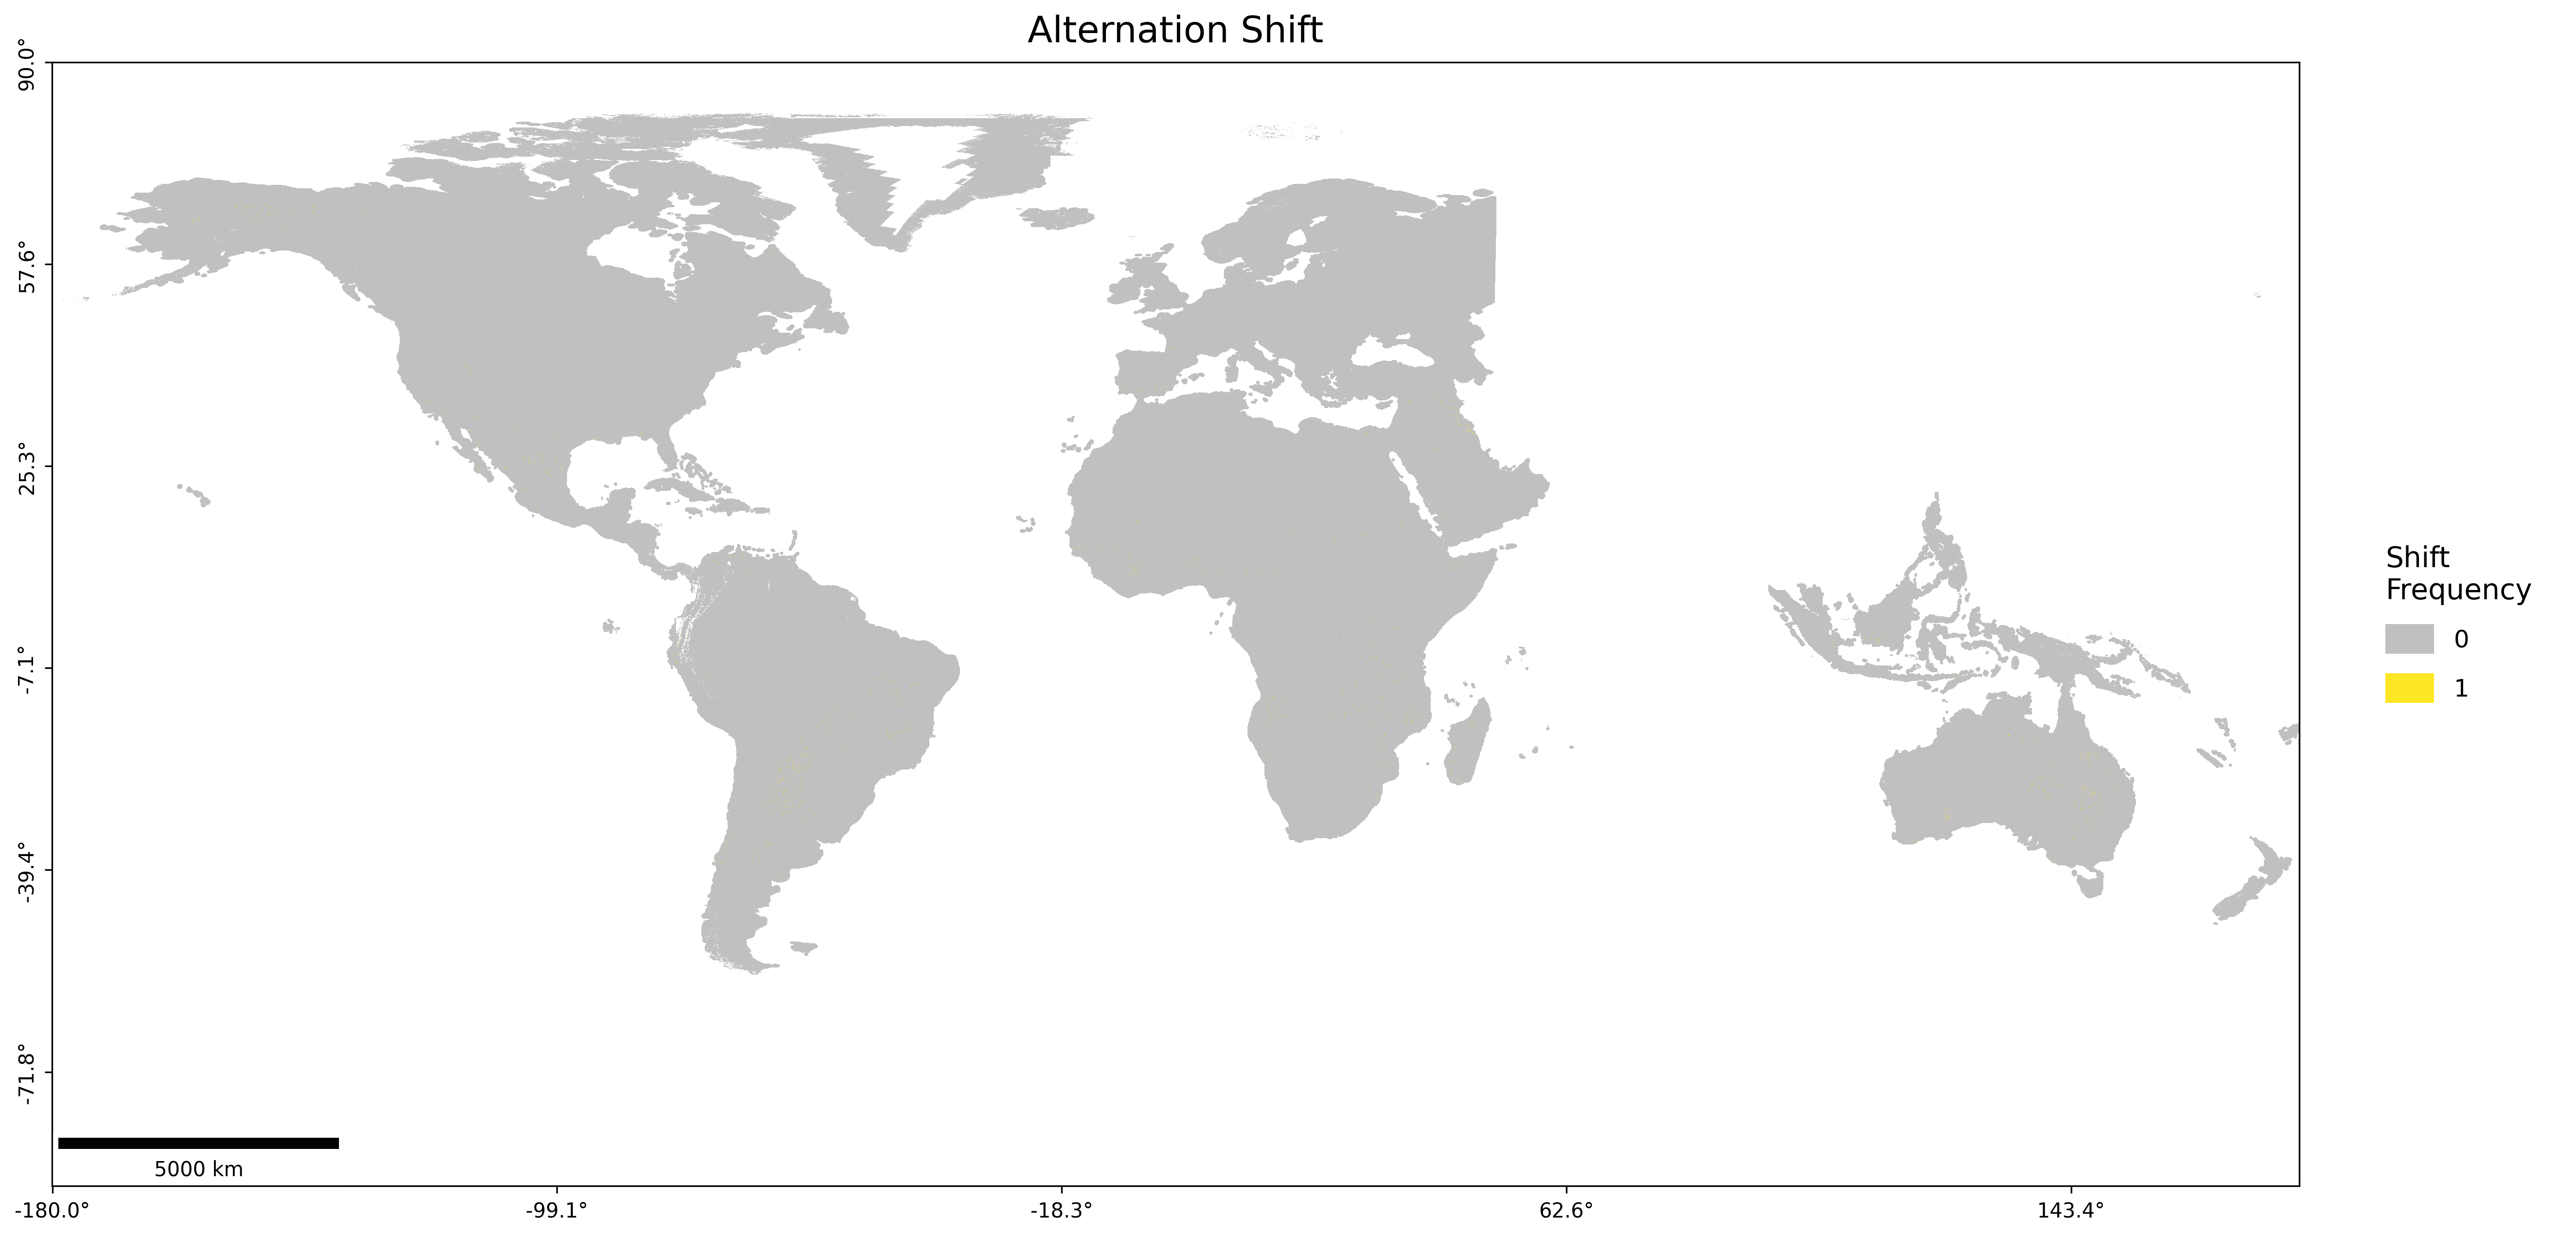

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_Global_Transitions_300m/maps/map_alternation_shift.png


In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function
print("Generating the global Alternation Shift map from GEE rasters...")
raster_prefix = f"Alternation_Shift_{years_to_process[0]}_{years_to_process[-1]}"

try:
    utils.plot_alternation_shift_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename=raster_prefix,
        scale_factor=0.05,
    )
except Exception as e:
    print(f"\nError running the function: {e}")